In [34]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [35]:
df = pd.read_csv('hmeq.csv')    

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

num_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop('BAD')
cat_cols = df.select_dtypes(include=['object']).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna('Unknown')

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

X = df.drop('BAD', axis=1)
y = df['BAD']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (4768, 12)
Test shape: (1192, 12)


In [41]:
from sklearn.metrics import confusion_matrix

cost_fn = 10  
cost_fp = 1   


y_prob = rf_model.predict_proba(X_test)[:, 1]


thresholds = np.arange(0.1, 0.9, 0.05)
costs = []

best_threshold = 0.5
min_cost = float('inf')

for thresh in thresholds:
    y_pred_thresh = (y_prob >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thresh).ravel()
    
    total_cost = (fp * cost_fp) + (fn * cost_fn)
    costs.append(total_cost)
    
    if total_cost < min_cost:
        min_cost = total_cost
        best_threshold = thresh

print(f" Best Threshold: {best_threshold:.2f}")
print(f" Minimum Total Business Cost: {min_cost}")


 Best Threshold: 0.10
 Minimum Total Business Cost: 281


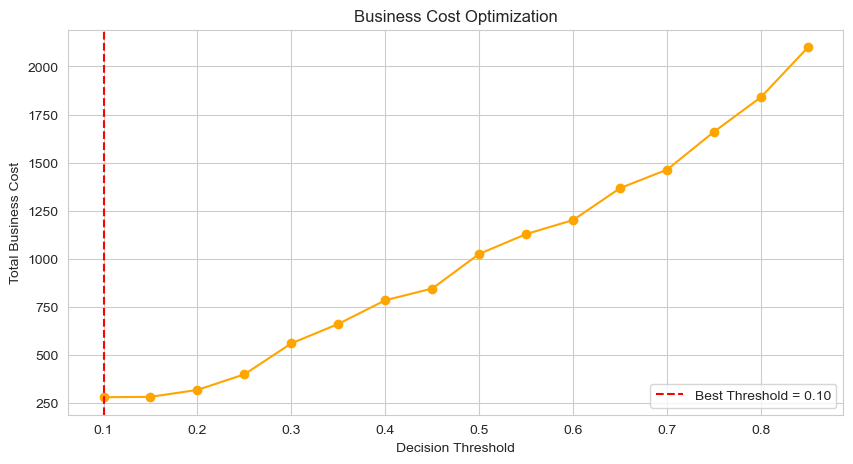

In [42]:

plt.figure(figsize=(10,5))
plt.plot(thresholds, costs, marker='o', color='orange')
plt.xlabel('Decision Threshold')
plt.ylabel('Total Business Cost')
plt.title('Business Cost Optimization')
plt.axvline(x=best_threshold, color='r', linestyle='--', label=f'Best Threshold = {best_threshold:.2f}')
plt.legend()
plt.show()

In [43]:
from sklearn.metrics import confusion_matrix, classification_report
y_pred_final = (y_prob >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_final))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.99      0.80      0.88       954
           1       0.55      0.96      0.70       238

    accuracy                           0.83      1192
   macro avg       0.77      0.88      0.79      1192
weighted avg       0.90      0.83      0.85      1192

Confusion Matrix:
[[763 191]
 [  9 229]]
